In [1]:
%pip install ipykernel 


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [16]:
docs = (
     PyPDFLoader("data/Company_Policies.pdf").load()
    + PyPDFLoader("data/Company_Profile.pdf").load()
    + PyPDFLoader("data/Product_and_Pricing.pdf").load())

In [17]:

chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)


print(chunks)

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'data/Company_Policies.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x7f\nSick Leave: 10 working days per year\n\x7f\nCasual Leave: 6 working days per year\n\x7f\nMaternity Leave: As per 

In [18]:
embedding=OllamaEmbeddings(model="nomic-embed-text:latest")

vector_store=FAISS.from_documents(embedding=embedding,documents=chunks)
reteriver=vector_store.as_retriever(search_kwargs={"k":5})
print(reteriver)


tags=['FAISS', 'OllamaEmbeddings'] vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x12d37ded0> search_kwargs={'k': 5}


In [19]:
llm=ChatOllama(model="qwen3:8b")

print(llm)

model='qwen3:8b'


In [20]:
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]     

    context: str # New
    answer: str

In [22]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [ ]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


def retrieve(state: State):
    return {"docs": reteriver.invoke(state["question"])}

In [24]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

In [25]:
Rag_generation_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",
         "you are business Rag assistant.\n"
         "answer the user question using only the context provided"
         "if the context does not content any information answer i do not have the information"),
         ("human",
          "Question:{question}\n\n"
          "Context:{context}")
    ]
)

def generate_context_from_doc(state:State):
    context="\n\n--\n\n".join(
        [context.page_content for context in state.get("relevant_docs",[])]
    ).strip()

    if not context:
        return {"asnwer":"do not have the relevant context for the question"}
    result=llm.invoke(Rag_generation_prompt.format_prompt(
        question=state["question"],
        context=context
    ))

    return {
        "answer":result.content,"context":context
    }

In [26]:
def no_relevant_docs(state: State):
    return {"answer": "No relevant document found.", "context": ""}

In [27]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [29]:
def route_after_relevance(state: State) -> Literal["generate_context_from_doc", "no_relevant_docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_context_from_doc"
    return "no_relevant_docs"

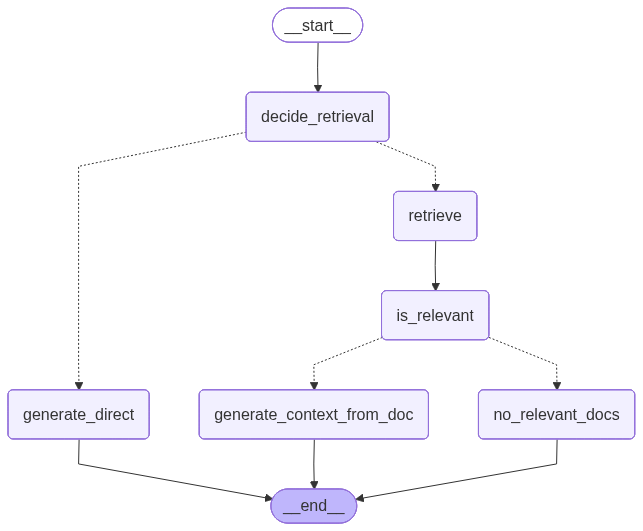

In [32]:
G=StateGraph(State)
G.add_node("decide_retrieval",decide_retrieval)
G.add_node("generate_direct",generate_direct)
G.add_node("retrieve",retrieve)
G.add_node("is_relevant",is_relevant)
G.add_node("generate_context_from_doc",generate_context_from_doc)
G.add_node("no_relevant_docs",no_relevant_docs)
G.add_edge(START,"decide_retrieval")
G.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct":"generate_direct",
        "retrieve":"retrieve"
    },
)
G.add_edge("generate_direct",END)
G.add_edge("retrieve","is_relevant")


G.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
       "generate_context_from_doc":"generate_context_from_doc",
        "no_relevant_docs":"no_relevant_docs"
    },
)

G.add_edge("generate_context_from_doc",END)
G.add_edge("no_relevant_docs",END)

App=G.compile()
App



In [34]:
App.invoke(
    {
       "question":"what is the leave policy of NexaAI?" ,
       "need_retrieval":True,
       
       
    }
)

: 